In [1]:
#Задание 1
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import binom

In [2]:
# Загружаем данные
companies = pd.read_csv('/content/01_crm_companies.csv')
transactions = pd.read_csv('/content/02_crm_transactions.csv')
lms_events = pd.read_csv('/content/03_lms_events.csv')
finance = pd.read_csv('/content/05_finance_payments.csv')
products = pd.read_csv('/content/09_products.csv')

In [3]:
# Посмотрим на первые строки
print(companies.head())
print(transactions.head())
print(lms_events.head())
print(finance.head())
print(products.head())

   company_id            company_name         inn      industry region  \
0        1001           ООО "Ромашка"  7701123456        Retail    ЦФО   
1        1002        АО "ТехноСервис"  7802123456            IT   СЗФО   
2        1003              ИП Сидоров  6103123456      Services    ЮФО   
3        1004  ООО "Ромашка-Логистик"  7701123456     Logistics    ЦФО   
4        1005       ЗАО "СтройИнвест"  1604123456  Construction    ПФО   

   employee_count created_date    status  
0             120   2023-05-15    active  
1              45   2023-08-20    active  
2               5   2024-01-10      lead  
3              30   2024-02-15    active  
4             250   2022-11-05  inactive  
  transaction_id  company_id transaction_date product_id  quantity  \
0           D001        1001       2025-01-15       P001        10   
1           D002        1001       2025-02-10       P002         5   
2           D003        1002       2025-01-20       P003         8   
3           D004 

In [4]:
# Анализ пропусков и проблем в данных

def analyze_df(df, name):
    print(f"\n--- {name} ---")
    print(f"Размер: {df.shape}")

    # Пропуски
    missing = df.isnull().sum()
    missing_data = missing[missing > 0]
    if len(missing_data) > 0:
        print(f"Пропуски: {missing_data.to_dict()}")
    else:
        print("Пропуски: отсутствуют")

    # Числовые статистики
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(f"Статистики числовых полей:")
        print(df[numeric_cols].describe())

# Анализируем каждый файл
analyze_df(companies, "01_crm_companies.csv")
analyze_df(transactions, "02_crm_transactions.csv")
analyze_df(lms_events, "03_lms_events.csv")
analyze_df(finance, "05_finance_payments.csv")
analyze_df(products, "09_products.csv")

# Проверка форматов дат
print("\n" + "=" * 60)
print("ПРОВЕРКА ФОРМАТОВ ДАТ")
print("=" * 60)

print(f"companies['created_date']: тип={companies['created_date'].dtype}, пример={companies['created_date'].iloc[0]}")
print(f"transactions['transaction_date']: тип={transactions['transaction_date'].dtype}, пример={transactions['transaction_date'].iloc[0]}")
print(f"lms_events['event_date']: тип={lms_events['event_date'].dtype}, пример={lms_events['event_date'].iloc[0]}")
print(f"finance['doc_date']: тип={finance['doc_date'].dtype}, пример={finance['doc_date'].iloc[0]}")

print("\n Обнаруженные проблемы:")
print("  1. finance['doc_date'] в формате ДД.ММ.ГГГГ (требует преобразования)")
print("  2. lms_events['event_date'] содержит время (требуется извлечение даты)")


--- 01_crm_companies.csv ---
Размер: (40, 8)
Пропуски: отсутствуют
Статистики числовых полей:
        company_id           inn  employee_count
count    40.000000  4.000000e+01       40.000000
mean   1020.500000  6.275273e+09       94.175000
std      11.690452  2.279156e+09      111.086681
min    1001.000000  1.604123e+09        1.000000
25%    1010.750000  6.117623e+09       17.250000
50%    1020.500000  7.708623e+09       50.000000
75%    1030.250000  7.733373e+09      120.000000
max    1040.000000  7.838123e+09      420.000000

--- 02_crm_transactions.csv ---
Размер: (42, 10)
Пропуски: отсутствуют
Статистики числовых полей:
        company_id   quantity     unit_price   total_amount  probability
count    42.000000  42.000000      42.000000      42.000000    42.000000
mean   1019.595238   5.285714   32146.833333  151642.857143    90.000000
std      12.133524   3.402192   36723.679929  117010.906606    22.631728
min    1001.000000   1.000000   11667.000000   15000.000000    20.000000


In [5]:
# Задание 2. Очистка и подготовка данных
# 2.1 Очистка финансовых данных
print("\n2.1 Очистка финансовых данных...")
finance_clean = finance[
    (finance['payment_type'] == 'payment') &
    (finance['amount'] > 0)
].copy()
print(f"  Исходно записей: {len(finance)}")
print(f"  После фильтрации (payment, amount>0): {len(finance_clean)}")

# 2.2 Преобразование дат
# Финансы: формат ДД.ММ.ГГГГ (колонка называется doc_date)
finance_clean['doc_date'] = pd.to_datetime(finance_clean['doc_date'], format='%d.%m.%Y')
# Транзакции: формат YYYY-MM-DD
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
# LMS: извлекаем только дату
lms_events['event_date'] = pd.to_datetime(lms_events['event_date'].str.split().str[0])
# Компании
companies['created_date'] = pd.to_datetime(companies['created_date'])

# 2.3 Проверка дубликатов
print("\n2.3 Проверка дубликатов...")

def check_dups(df, key, name):
    dups = df[key].duplicated().sum()
    print(f"  {name}: {dups} дубликатов по {key}")

check_dups(companies, 'company_id', 'companies')
check_dups(transactions, 'transaction_id', 'transactions')
check_dups(lms_events, 'event_id', 'lms_events')
check_dups(finance_clean, 'payment_id', 'finance')
check_dups(products, 'product_id', 'products')


2.1 Очистка финансовых данных...
  Исходно записей: 43
  После фильтрации (payment, amount>0): 38

2.3 Проверка дубликатов...
  companies: 0 дубликатов по company_id
  transactions: 0 дубликатов по transaction_id
  lms_events: 0 дубликатов по event_id
  finance: 0 дубликатов по payment_id
  products: 0 дубликатов по product_id


In [6]:
# Задание 3. Расчет метрик для витрины
# 3.1 Определение даты отсчета
print("\n3.1 Определение даты отсчета...")
cutoff_date = pd.to_datetime('2025-03-31')
lookback_90 = cutoff_date - pd.Timedelta(days=90)
print(f"  cutoff_date: {cutoff_date.date()}")
print(f"  lookback_90: {lookback_90.date()}")

# 3.2 Расчет активности в LMS
print("\n3.2 Расчет активности в LMS...")
lms_logins = lms_events[
    (lms_events['event_type'] == 'login') &
    (lms_events['event_date'] >= lookback_90)
]
lms_activity = lms_logins.groupby('company_id').agg(
    login_count_90d=('event_id', 'count')
).reset_index()
lms_activity['is_active_lms'] = 1
print(f"  Компаний с активностью за 90 дней: {len(lms_activity)}")

# 3.3 Расчет стабильности платежей (по CRM сделкам, как в инструкции)
print("\n3.3 Расчет стабильности платежей...")
deals_total = transactions.groupby('company_id').size().reset_index(name='total_deals')
deals_success = transactions[transactions['transaction_stage'] == 'closed_won'].groupby('company_id').size().reset_index(name='successful_deals')
payment_stability_df = deals_total.merge(deals_success, on='company_id', how='left')
payment_stability_df['successful_deals'] = payment_stability_df['successful_deals'].fillna(0)
payment_stability_df['payment_stability'] = payment_stability_df['successful_deals'] / payment_stability_df['total_deals']
print(f"  Компаний с данными по сделкам: {len(payment_stability_df)}")

# 3.4 Расчет среднего чека
print("\n3.4 Расчет среднего чека...")
closed_won = transactions[transactions['transaction_stage'] == 'closed_won']
company_avg_check = closed_won.groupby('company_id')['total_amount'].mean().reset_index(name='avg_check')
company_total_revenue = closed_won.groupby('company_id')['total_amount'].sum().reset_index(name='total_revenue')
print(f"  Компаний с успешными сделками: {len(company_avg_check)}")


3.1 Определение даты отсчета...
  cutoff_date: 2025-03-31
  lookback_90: 2024-12-31

3.2 Расчет активности в LMS...
  Компаний с активностью за 90 дней: 24

3.3 Расчет стабильности платежей...
  Компаний с данными по сделкам: 38

3.4 Расчет среднего чека...
  Компаний с успешными сделками: 31


In [7]:
# Задание 4. Сборка витрины company_readiness_for_pro

# 4.1 Объединение данных
print("\n4.1 Объединение данных...")
ready_df = companies[['company_id', 'company_name', 'industry', 'region', 'employee_count', 'status']].copy()
print(f"  Исходное количество компаний: {len(ready_df)}")

ready_df = ready_df.merge(lms_activity[['company_id', 'is_active_lms', 'login_count_90d']], on='company_id', how='left')
ready_df = ready_df.merge(payment_stability_df[['company_id', 'payment_stability']], on='company_id', how='left')
ready_df = ready_df.merge(company_avg_check[['company_id', 'avg_check']], on='company_id', how='left')
ready_df = ready_df.merge(company_total_revenue[['company_id', 'total_revenue']], on='company_id', how='left')

# 4.2 Заполнение пропусков
print("\n4.2 Заполнение пропусков...")
fill_cols = ['is_active_lms', 'login_count_90d', 'payment_stability', 'avg_check', 'total_revenue']
for col in fill_cols:
    ready_df[col] = ready_df[col].fillna(0)

# 4.3 Расчет интегрального показателя готовности
print("\n4.3 Расчет readiness_score...")
max_avg_check = ready_df['avg_check'].max()
ready_df['norm_avg_check'] = ready_df['avg_check'] / max_avg_check if max_avg_check > 0 else 0

ready_df['readiness_score'] = (
    ready_df['is_active_lms'] * 0.3 +
    ready_df['payment_stability'] * 0.4 +
    ready_df['norm_avg_check'] * 0.3
)

print(f"  max_avg_check: {max_avg_check:,.0f} руб.")
print(f"  readiness_score - среднее: {ready_df['readiness_score'].mean():.3f}")
print(f"  readiness_score - медиана: {ready_df['readiness_score'].median():.3f}")
print(f"  readiness_score - мин: {ready_df['readiness_score'].min():.3f}")
print(f"  readiness_score - макс: {ready_df['readiness_score'].max():.3f}")

# 4.4 Сохранение витрины
print("\n4.4 Сохранение витрины...")
ready_df.to_csv('company_readiness_for_pro.csv', index=False)

print("\nПервые 5 строк витрины:")
print(ready_df[['company_id', 'company_name', 'is_active_lms', 'payment_stability', 'avg_check', 'readiness_score']].head())


4.1 Объединение данных...
  Исходное количество компаний: 40

4.2 Заполнение пропусков...

4.3 Расчет readiness_score...
  max_avg_check: 500,000 руб.
  readiness_score - среднее: 0.562
  readiness_score - медиана: 0.728
  readiness_score - мин: 0.000
  readiness_score - макс: 1.000

4.4 Сохранение витрины...

Первые 5 строк витрины:
   company_id            company_name  is_active_lms  payment_stability  \
0        1001           ООО "Ромашка"            1.0                1.0   
1        1002        АО "ТехноСервис"            1.0                1.0   
2        1003              ИП Сидоров            1.0                1.0   
3        1004  ООО "Ромашка-Логистик"            0.0                0.0   
4        1005       ЗАО "СтройИнвест"            1.0                1.0   

   avg_check  readiness_score  
0   175000.0           0.8050  
1   335000.0           0.9010  
2    82500.0           0.7495  
3        0.0           0.0000  
4   500000.0           1.0000  


In [8]:
# Задание 5. Оценка параметров воронки (n)

# 5.1 Определение порога готовности
print("\n5.1 Определение порога готовности...")
print(f"  Медиана: {ready_df['readiness_score'].median():.3f}")
print(f"  70-й процентиль: {ready_df['readiness_score'].quantile(0.7):.3f}")
print(f"  80-й процентиль: {ready_df['readiness_score'].quantile(0.8):.3f}")

# ВЫБЕРИТЕ ПОРОГ (рекомендуется 70-й процентиль)
threshold = ready_df['readiness_score'].quantile(0.7)
print(f"\n ВЫБРАН ПОРОГ: {threshold:.3f} (70-й процентиль)")

# 5.2 Формирование списка потенциальных клиентов
print("\n5.2 Формирование списка потенциальных клиентов...")
ready_companies = ready_df[ready_df['readiness_score'] >= threshold].copy()
n = len(ready_companies)
print(f"  Количество потенциальных клиентов (n) = {n}")
print(f"  Это {n/len(ready_df)*100:.1f}% от всех компаний")


5.1 Определение порога готовности...
  Медиана: 0.728
  70-й процентиль: 0.759
  80-й процентиль: 0.798

 ВЫБРАН ПОРОГ: 0.759 (70-й процентиль)

5.2 Формирование списка потенциальных клиентов...
  Количество потенциальных клиентов (n) = 12
  Это 30.0% от всех компаний


In [9]:
# Посмотрим, какие продукты есть в справочнике
print(products)

   product_id                      product_name  product_type   price  \
0        P001                 Excel для бизнеса        course  150000   
1        P002              Управление проектами        course  200000   
2        P003                         Лидерство        course  150000   
3        P004                  Аналитика данных        course  250000   
4        P005                        Переговоры        course  180000   
5        P006         Финансы для нефинансистов        course  220000   
6        P007             Python для начинающих        course  280000   
7        P008  Корпоративная подписка "Базовый"  subscription  250000   
8        P009                    Подписка "Pro"  subscription  350000   
9        P010        Доступ к библиотеке курсов  subscription   50000   
10       P011                 Премиум-поддержка       service   75000   
11       P012   Индивидуальная разработка курса       service  150000   
12       P013     Корпоративная подписка "Lite"    

In [11]:
# Выбор аналогов и расчет вероятности p
analog_list = ['P004', 'P007', 'P009']

print(f"\n  Выбраны продукты-аналоги: {analog_list}")

print("\n5.4 Оценка исторической конверсии...")
analog_deals = transactions[
    (transactions['product_id'].isin(analog_list)) &
    (transactions['transaction_stage'] == 'closed_won')
]
analog_buyers = set(analog_deals['company_id'].unique())
print(f"  Компаний, покупавших аналоги: {len(analog_buyers)}")

ready_ids = set(ready_companies['company_id'])
intersection = ready_ids & analog_buyers
p = len(intersection) / n if n > 0 else 0

print(f"  Пересечение (готовы И покупали аналоги): {len(intersection)}")
print(f"  Вероятность покупки (p) = {p:.3f} ({p*100:.1f}%)")


  Выбраны продукты-аналоги: ['P004', 'P007', 'P009']

5.4 Оценка исторической конверсии...
  Компаний, покупавших аналоги: 9
  Пересечение (готовы И покупали аналоги): 2
  Вероятность покупки (p) = 0.167 (16.7%)



6.1 Расчет основных характеристик...
  Ожидаемое число продаж (μ) = 2.0
  Стандартное отклонение (σ) = 1.29
  95% ДИ для числа продаж: [0, 5]

6.2 Оценка вероятности достижения KPI...
  P(k ≥ 5) = 3.6% (выполнение KPI)
  P(k < 5) = 96.4% (риск невыполнения)
  P(k ≥ 8) = 0.0% (цель-амбиция)
  P(5 ≤ k ≤ 8) = 3.6% (целевой диапазон)

6.3 Построение графиков...


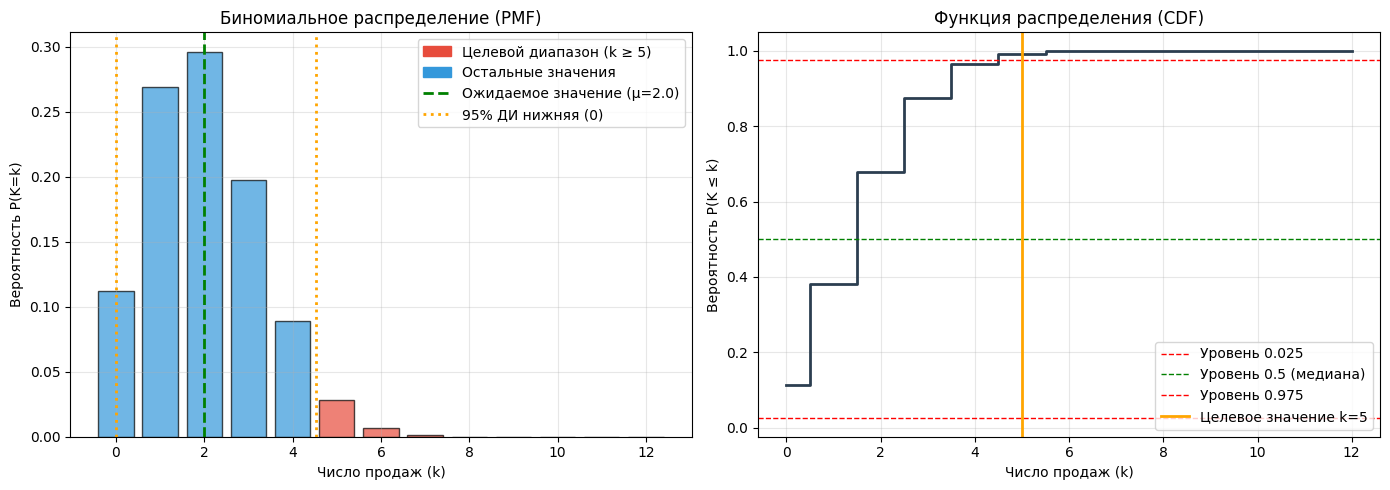

In [12]:
# Задание 6. Вероятностное моделирование

from scipy.stats import binom
import matplotlib.pyplot as plt
import numpy as np

# 6.1 Расчет основных характеристик
print("\n6.1 Расчет основных характеристик...")
mu = n * p
sigma = np.sqrt(n * p * (1 - p))
lower_sales = max(0, mu - 1.96 * sigma)
upper_sales = mu + 1.96 * sigma

print(f"  Ожидаемое число продаж (μ) = {mu:.1f}")
print(f"  Стандартное отклонение (σ) = {sigma:.2f}")
print(f"  95% ДИ для числа продаж: [{lower_sales:.0f}, {upper_sales:.0f}]")

# 6.2 Оценка вероятности достижения KPI
print("\n6.2 Оценка вероятности достижения KPI...")
if n > 0:
    prob_ge_5 = 1 - binom.cdf(4, int(n), p)
    prob_lt_5 = binom.cdf(4, int(n), p)
    prob_ge_8 = 1 - binom.cdf(7, int(n), p)
    prob_5_8 = binom.cdf(8, int(n), p) - binom.cdf(4, int(n), p)

    print(f"  P(k ≥ 5) = {prob_ge_5*100:.1f}% (выполнение KPI)")
    print(f"  P(k < 5) = {prob_lt_5*100:.1f}% (риск невыполнения)")
    print(f"  P(k ≥ 8) = {prob_ge_8*100:.1f}% (цель-амбиция)")
    print(f"  P(5 ≤ k ≤ 8) = {prob_5_8*100:.1f}% (целевой диапазон)")

# 6.3 Визуализация распределения
print("\n6.3 Построение графиков...")

# Диапазон значений k (от 0 до n или до разумного предела)
k_max = min(int(n), int(mu + 5 * sigma) + 5)
k_values = np.arange(0, k_max + 1)

# Вероятности для каждого k
probabilities = [binom.pmf(k, int(n), p) for k in k_values]

# График 1: Функция вероятности (pmf)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Цвета: красный для целевого диапазона (k >= 5), синий для остальных
colors = ['#3498db' if k < 5 else '#e74c3c' for k in k_values]

ax1.bar(k_values, probabilities, color=colors, edgecolor='black', alpha=0.7)
ax1.axvline(mu, color='green', linestyle='--', linewidth=2, label=f'Ожидаемое значение (μ={mu:.1f})')
ax1.axvline(lower_sales, color='orange', linestyle=':', linewidth=2, label=f'95% ДИ нижняя ({lower_sales:.0f})')
ax1.axvline(upper_sales, color='orange', linestyle=':', linewidth=2, label=f'95% ДИ верхняя ({upper_sales:.0f})')
ax1.set_xlabel('Число продаж (k)')
ax1.set_ylabel('Вероятность P(K=k)')
ax1.set_title('Биномиальное распределение (PMF)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Добавим подпись для красной зоны
from matplotlib.patches import Patch
red_patch = Patch(color='#e74c3c', label='Целевой диапазон (k ≥ 5)')
blue_patch = Patch(color='#3498db', label='Остальные значения')
ax1.legend(handles=[red_patch, blue_patch,
                    ax1.get_lines()[0], ax1.get_lines()[1]],
           loc='upper right')

# График 2: Функция распределения (cdf)
cdf_values = [binom.cdf(k, int(n), p) for k in k_values]
ax2.step(k_values, cdf_values, where='mid', linewidth=2, color='#2c3e50')
ax2.axhline(y=0.025, color='red', linestyle='--', linewidth=1, label='Уровень 0.025')
ax2.axhline(y=0.5, color='green', linestyle='--', linewidth=1, label='Уровень 0.5 (медиана)')
ax2.axhline(y=0.975, color='red', linestyle='--', linewidth=1, label='Уровень 0.975')
ax2.axvline(x=5, color='orange', linestyle='-', linewidth=2, label='Целевое значение k=5')
ax2.set_xlabel('Число продаж (k)')
ax2.set_ylabel('Вероятность P(K ≤ k)')
ax2.set_title('Функция распределения (CDF)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Количество сделок по аналогам: 9
Средний чек: 82,222 руб.
Медиана: 75,000 руб.
Минимум: 30,000 руб.
Максимум: 150,000 руб.
Коэффициент асимметрии: 0.53


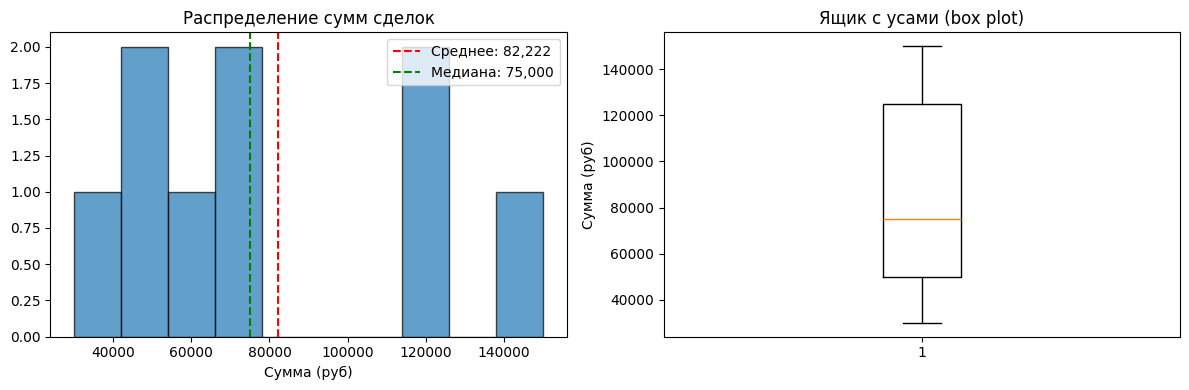

In [13]:
# Задание 7. Анализ распределения среднего чека

# Берем суммы сделок по выбранным аналогам
analog_deals = transactions[
    (transactions['product_id'].isin(analog_list)) &
    (transactions['transaction_stage'] == 'closed_won')
]

amounts = analog_deals['total_amount'].values

print(f"Количество сделок по аналогам: {len(amounts)}")
print(f"Средний чек: {amounts.mean():,.0f} руб.")
print(f"Медиана: {np.median(amounts):,.0f} руб.")
print(f"Минимум: {amounts.min():,.0f} руб.")
print(f"Максимум: {amounts.max():,.0f} руб.")
print(f"Коэффициент асимметрии: {pd.Series(amounts).skew():.2f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма
axes[0].hist(amounts, bins=10, edgecolor='black', alpha=0.7)
axes[0].axvline(amounts.mean(), color='red', linestyle='--', label=f'Среднее: {amounts.mean():,.0f}')
axes[0].axvline(np.median(amounts), color='green', linestyle='--', label=f'Медиана: {np.median(amounts):,.0f}')
axes[0].set_title('Распределение сумм сделок')
axes[0].set_xlabel('Сумма (руб)')
axes[0].legend()

# Box plot
axes[1].boxplot(amounts, vert=True)
axes[1].set_title('Ящик с усами (box plot)')
axes[1].set_ylabel('Сумма (руб)')

plt.tight_layout()
plt.show()

if pd.Series(amounts).skew() > 1:
    print("\n Распределение сильно скошено (асимметрия > 1)")
    print("   Это нормально для финансовых данных, но требует бутстрапа")

Средний чек (исходный): 82,222 руб.
95% доверительный интервал (бутстрап):
  от 58,333 до 108,333 руб.

Наивный нормальный интервал:
  от 55,082 до 109,363 руб.

Сравнение:
  Бутстрап интервал шире на -4,281 руб.
 Бутстрап лучше подходит для скошенных данных


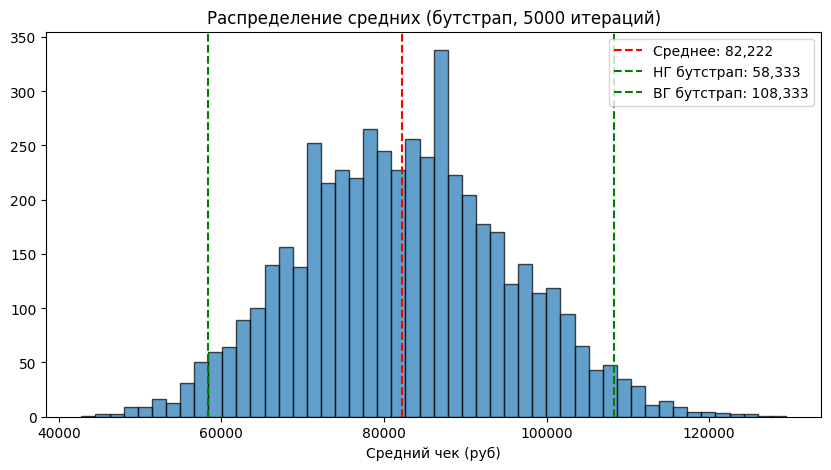

In [14]:
# Задание 8. Бутстрап для доверительного интервала среднего чека

# Бутстрап: 5000 псевдовыборок
boot_means = []
for i in range(5000):
    sample = np.random.choice(amounts, size=len(amounts), replace=True)
    boot_means.append(sample.mean())

# Доверительный интервал
check_lower = np.percentile(boot_means, 2.5)
check_upper = np.percentile(boot_means, 97.5)

print(f"Средний чек (исходный): {amounts.mean():,.0f} руб.")
print(f"95% доверительный интервал (бутстрап):")
print(f"  от {check_lower:,.0f} до {check_upper:,.0f} руб.")

# Наивный нормальный интервал (для сравнения)
se = np.std(amounts, ddof=1) / np.sqrt(len(amounts))
naive_lower = amounts.mean() - 1.96 * se
naive_upper = amounts.mean() + 1.96 * se
print(f"\nНаивный нормальный интервал:")
print(f"  от {naive_lower:,.0f} до {naive_upper:,.0f} руб.")

# Сравнение
print(f"\nСравнение:")
print(f"  Бутстрап интервал шире на {(check_upper - check_lower) - (naive_upper - naive_lower):,.0f} руб.")
print(f" Бутстрап лучше подходит для скошенных данных")

# Визуализация
plt.figure(figsize=(10, 5))
plt.hist(boot_means, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(amounts.mean(), color='red', linestyle='--', label=f'Среднее: {amounts.mean():,.0f}')
plt.axvline(check_lower, color='green', linestyle='--', label=f'НГ бутстрап: {check_lower:,.0f}')
plt.axvline(check_upper, color='green', linestyle='--', label=f'ВГ бутстрап: {check_upper:,.0f}')
plt.title('Распределение средних (бутстрап, 5000 итераций)')
plt.xlabel('Средний чек (руб)')
plt.legend()
plt.show()

In [15]:
# Задание 9. Итоговый прогноз выручки

# Точечный прогноз
expected_revenue = mu * amounts.mean()
print(f"Точечный прогноз выручки: {expected_revenue:,.0f} руб.")
print(f"  ({expected_revenue/1e6:.1f} млн руб.)")

# Интервальный прогноз (пессимистичный и оптимистичный)
revenue_lower = lower_sales * check_lower
revenue_upper = upper_sales * check_upper

print(f"\nИнтервальный прогноз (95%):")
print(f"  от {revenue_lower:,.0f} руб. ({revenue_lower/1e6:.1f} млн руб.)")
print(f"  до {revenue_upper:,.0f} руб. ({revenue_upper/1e6:.1f} млн руб.)")

# Сводная таблица
print("\n" + "=" * 50)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 50)
print(f"{'Показатель':<25} {'Точечный':<15} {'95% ДИ нижняя':<15} {'95% ДИ верхняя':<15}")
print("-" * 70)
print(f"{'Число продаж':<25} {mu:<15.1f} {lower_sales:<15.0f} {upper_sales:<15.0f}")
print(f"{'Средний чек (руб)':<25} {amounts.mean():<15,.0f} {check_lower:<15,.0f} {check_upper:<15,.0f}")
print(f"{'Выручка (руб)':<25} {expected_revenue:<15,.0f} {revenue_lower:<15,.0f} {revenue_upper:<15,.0f}")
print(f"{'Выручка (млн руб)':<25} {expected_revenue/1e6:<15.1f} {revenue_lower/1e6:<15.1f} {revenue_upper/1e6:<15.1f}")
print("-" * 70)

print("\n" + "=" * 50)
print("ИНТЕРПРЕТАЦИЯ ДЛЯ ФИНАНСОВОГО ДИРЕКТОРА")
print("=" * 50)
print(f" Вероятность выполнить план (≥5 продаж): {prob_ge_5*100:.1f}%")
print(f" Ожидаемая выручка: {expected_revenue/1e6:.1f} млн руб.")
print(f" Риск невыполнения плана: {prob_lt_5*100:.1f}%")
print(f" Диапазон выручки: от {revenue_lower/1e6:.1f} до {revenue_upper/1e6:.1f} млн руб.")
print("=" * 50)

Точечный прогноз выручки: 164,444 руб.
  (0.2 млн руб.)

Интервальный прогноз (95%):
  от 0 руб. (0.0 млн руб.)
  до 490,788 руб. (0.5 млн руб.)

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
Показатель                Точечный        95% ДИ нижняя   95% ДИ верхняя 
----------------------------------------------------------------------
Число продаж              2.0             0               5              
Средний чек (руб)         82,222          58,333          108,333        
Выручка (руб)             164,444         0               490,788        
Выручка (млн руб)         0.2             0.0             0.5            
----------------------------------------------------------------------

ИНТЕРПРЕТАЦИЯ ДЛЯ ФИНАНСОВОГО ДИРЕКТОРА
 Вероятность выполнить план (≥5 продаж): 3.6%
 Ожидаемая выручка: 0.2 млн руб.
 Риск невыполнения плана: 96.4%
 Диапазон выручки: от 0.0 до 0.5 млн руб.


In [22]:
# Задание 10. Сохраняем результаты в файлы

# Сохраняем витрину (уже есть)
ready_df.to_csv('company_readiness_for_pro.csv', index=False)

# Создаем файл с основными цифрами для отчета
with open('forecast_results.txt', 'w', encoding='utf-8') as f:
    f.write("РЕЗУЛЬТАТЫ ПРОГНОЗА ПОДПИСКИ PRO\n")
    f.write("=" * 40 + "\n")
    f.write(f"Потенциальных клиентов (n): {n}\n")
    f.write(f"Вероятность покупки (p): {p:.3f} ({p*100:.1f}%)\n")
    f.write(f"Ожидаемое число продаж: {mu:.1f}\n")
    f.write(f"95% ДИ числа продаж: [{lower_sales:.0f}, {upper_sales:.0f}]\n")
    f.write(f"Средний чек: {amounts.mean():,.0f} руб.\n")
    f.write(f"95% ДИ среднего чека: [{check_lower:.0f}, {check_upper:.0f}] руб.\n")
    f.write(f"Ожидаемая выручка: {expected_revenue/1e6:.1f} млн руб.\n")
    f.write(f"95% ДИ выручки: [{revenue_lower/1e6:.1f}, {revenue_upper/1e6:.1f}] млн руб.\n")
    f.write(f"Вероятность KPI (≥5): {prob_ge_5*100:.1f}%\n")